# Pipeline 7.55 — стабильная версия

Это ноутбук с твоим рабочим пайплайном, который давал около **7.55 MAE**.

Сохранил логику без спорных доработок:

- CatBoost `cat_mae_direct`;
- XGBoost residual;
- LightGBM residual;
- HistGradientBoosting quantile-модели;
- финальный blend по весам;
- физические признаки;
- `p_theory`;
- `p_empirical`;
- EMA;
- NWP-соседи;
- диагностика на последних 20% train.

Ожидаемые файлы:

```text
data/merged_dataset.csv
data/merged_valid_dataset.csv
```

Финальный файл сохраняется сюда:

```text
outputs/pipeline_755/submission_final_755.csv
```

## Импорты, константы и пути

In [ ]:
# -*- coding: utf-8 -*-

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

from sklearn.ensemble import HistGradientBoostingRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import seaborn as sns

warnings.filterwarnings("ignore")

# Константы турбин и физики
RANDOM_STATE = 42
INSTALLED_CAPACITY_MW = 90.09
TURBINES_TOTAL = 26
CUT_IN_SPEED = 3.0
RATED_SPEED = 12.0
CUT_OUT_SPEED = 25.0
AIR_DENSITY_REF = 1.225
EPS = 1e-6

NWP_SHIFTS = [-6, -3, -2, -1, 1, 2, 3, 6]

# Пути
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs") / "pipeline_755"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "merged_dataset.csv"
VALID_PATH = DATA_DIR / "merged_valid_dataset.csv"
FINAL_SUBMISSION_PATH = OUTPUT_DIR / "submission_final_755.csv"

# Оптимальные веса (получены ранее через SLSQP на OOF)
BLEND_WEIGHTS = {
    "cat_mae_direct": 0.361831,
    "hgb_q545": 0.235409,
    "xgb_residual": 0.177644,
    "hgb_q570": 0.116581,
    "lgb_residual": 0.064663,
    "hgb_q530": 0.043873
}

## 1. Загрузка данных

In [2]:
print("1. Загрузка данных...")
train_raw = pd.read_csv(TRAIN_PATH)
valid_raw = pd.read_csv(VALID_PATH)

target_col = [col for col in train_raw.columns if col not in valid_raw.columns][0]
repair_col = train_raw.columns[-1]

train = train_raw.rename(
    columns={
        "METEOFORECASTHOUR_OPENM_Datetime": "datetime",
        target_col: "target",
        repair_col: "turbines_in_repair",
    }
).copy()

valid = valid_raw.rename(
    columns={
        "METEOFORECASTHOUR_OPENM_Datetime": "datetime",
        repair_col: "turbines_in_repair",
    }
).copy()

train["datetime"] = pd.to_datetime(train["datetime"])
valid["datetime"] = pd.to_datetime(valid["datetime"])

train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))
train["source"] = "train"
valid["source"] = "valid"

train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

1. Загрузка данных...


## 2. Базовые признаки: время, ветер, физика

In [3]:
print("2. Генерация базовых признаков (время и физика)...")
full = pd.concat([train, valid], ignore_index=True, sort=False)
full = full.sort_values("datetime").reset_index(drop=True)

# Временные признаки
full["month"] = full["datetime"].dt.month
full["hour_of_day"] = full["datetime"].dt.hour
full["dayofyear"] = full["datetime"].dt.dayofyear
full["dayofweek"] = full["datetime"].dt.dayofweek

full["hour_sin"] = np.sin(2 * np.pi * full["hour_of_day"] / 24)
full["hour_cos"] = np.cos(2 * np.pi * full["hour_of_day"] / 24)
full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12)
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12)
full["dayofyear_sin"] = np.sin(2 * np.pi * full["dayofyear"] / 366)
full["dayofyear_cos"] = np.cos(2 * np.pi * full["dayofyear"] / 366)

speed_cols = ["wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "wind_speed_180m"]
direction_cols = ["wind_direction_10m", "wind_direction_80m", "wind_direction_120m", "wind_direction_180m"]

for col in speed_cols:
    full[f"{col}_sq"] = full[col] ** 2
    full[f"{col}_cube"] = full[col] ** 3

for col in direction_cols:
    suffix = col.replace("wind_direction_", "")
    angle = np.deg2rad(full[col] * 1000)
    full[f"wind_dir_{suffix}_sin"] = np.sin(angle)
    full[f"wind_dir_{suffix}_cos"] = np.cos(angle)

full["ws_120_cube"] = full["wind_speed_120m"] ** 3
full["ws_diff_120_80"] = full["wind_speed_120m"] - full["wind_speed_80m"]
full["ws_diff_180_120"] = full["wind_speed_180m"] - full["wind_speed_120m"]
full["ws_ratio_120_80"] = full["wind_speed_120m"] / (full["wind_speed_80m"] + EPS)
full["gust_ratio_10m"] = full["wind_gusts_10m"] / (full["wind_speed_10m"] + EPS)

# Физика атмосферы и теоретическая мощность
temperature_mean = 0.5 * (full["temperature_80m"] + full["temperature_120m"])
full["air_density"] = (full["pressure_msl"] * 100) / (287.05 * (temperature_mean + 273.15))
full["density_ratio"] = (full["air_density"] / AIR_DENSITY_REF).clip(0.75, 1.30)

for height in [80, 120]:
    full[f"wind_speed_{height}m_density_corrected"] = (
        full[f"wind_speed_{height}m"] * (full["density_ratio"] ** (1 / 3))
    )
    full[f"wind_power_density_{height}m"] = 0.5 * full["air_density"] * full[f"wind_speed_{height}m"] ** 3

availability = ((TURBINES_TOTAL - full["turbines_in_repair"]).clip(0, TURBINES_TOTAL)) / TURBINES_TOTAL
full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW

for height in [80, 120]:
    speed = full[f"wind_speed_{height}m"].clip(lower=0)
    curve = ((speed**3 - CUT_IN_SPEED**3) / (RATED_SPEED**3 - CUT_IN_SPEED**3)).clip(0, 1)
    curve = curve.where(speed >= CUT_IN_SPEED, 0)
    curve = curve.where(speed < CUT_OUT_SPEED, 0)
    full[f"p_theory_{height}"] = INSTALLED_CAPACITY_MW * curve * availability

full["p_theory_mean_80_120"] = 0.5 * (full["p_theory_80"] + full["p_theory_120"])

2. Генерация базовых признаков (время и физика)...


## 3. EMA и NWP-соседи

In [4]:
print("3. Экспоненциальное сглаживание (EMA) и NWP-соседи...")
full = full.sort_values("datetime").reset_index(drop=True)
time_indexed = full.set_index("datetime")

# В Pandas для ewm удобнее задавать span (период).
# Предполагая, что данные у вас идут с шагом в 1 час:
ewm_spans = {"3h": 3, "5h": 5, "7h": 7}

for col in ["wind_speed_120m_cube", "p_theory_80", "p_theory_120", "wind_power_density_120m"]:
    for window_str, span_val in ewm_spans.items():
        full[f"{col}_smooth_{window_str}"] = (
            time_indexed[col]
            # span=span_val эквивалентно обычному окну
            # ignore_na=False помогает корректно обрабатывать пропуски
            .ewm(span=span_val, min_periods=1)
            .mean()
            .reindex(full["datetime"])
            .to_numpy()
        )
    # Считаем "остаток" (отклонение текущего значения от быстрого тренда)
    full[f"{col}_minus_smooth_3h"] = full[col] - full[f"{col}_smooth_3h"]

nwp_base_cols = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

for col in nwp_base_cols:
    for shift_hours in NWP_SHIFTS:
        shifted_datetime = full["datetime"] + pd.to_timedelta(shift_hours, unit="h")
        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"
        full[f"{col}_nwp_{label}"] = time_indexed[col].reindex(shifted_datetime).to_numpy()

3. Экспоненциальное сглаживание (EMA) и NWP-соседи...


## 4. Эмпирическая кривая мощности

In [5]:
print("4. Эмпирическая кривая мощности...")
train_base = full[full["source"].eq("train")].copy().sort_values("datetime").reset_index(drop=True)
valid_base = full[full["source"].eq("valid")].copy().sort_values("datetime").reset_index(drop=True)

def add_empirical_power_features(frame, reference):
    frame = frame.copy()
    reference = reference.copy()

    ref_available = reference["available_capacity_mw"].clip(lower=1.0)
    reference["cf_available"] = (reference["target"] / ref_available).clip(0, 1.15)

    for height in [80, 120]:
        speed_col = f"wind_speed_{height}m_density_corrected"
        bins = np.arange(0, 26.5, 0.5)

        ref = reference[[speed_col, "cf_available"]].dropna().copy()
        ref["bin_id"] = pd.cut(ref[speed_col], bins=bins, labels=False)

        curve = (
            ref.groupby("bin_id", as_index=False)
            .agg(cf=("cf_available", "median"), n=("cf_available", "size"))
        )
        curve = curve[curve["n"] >= 20].copy()
        curve["speed"] = bins[curve["bin_id"].astype(int)] + 0.25
        curve = curve.sort_values("speed")

        x = np.r_[0.0, curve["speed"].to_numpy(), CUT_OUT_SPEED]
        y = np.r_[0.0, np.maximum.accumulate(curve["cf"].to_numpy()), np.maximum.accumulate(curve["cf"].to_numpy())[-1]]

        unique_x, unique_idx = np.unique(x, return_index=True)
        unique_y = y[unique_idx]

        interpolator = PchipInterpolator(unique_x, unique_y, extrapolate=True)
        empirical_cf = np.clip(interpolator(frame[speed_col].clip(0, CUT_OUT_SPEED)), 0, 1.15)
        empirical_cf = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf)
        empirical_cf = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf)

        frame[f"p_empirical_{height}"] = empirical_cf * frame["available_capacity_mw"]
        frame[f"cf_empirical_{height}"] = empirical_cf

    frame["p_empirical_mean_80_120"] = 0.5 * (frame["p_empirical_80"] + frame["p_empirical_120"])
    frame["p_empirical_minus_theory_120"] = frame["p_empirical_120"] - frame["p_theory_120"]
    return frame

train_fe = add_empirical_power_features(train_base, train_base)
valid_fe = add_empirical_power_features(valid_base, train_base)

4. Эмпирическая кривая мощности...


## 5. Выбор признаков

In [6]:
# Отбираем фичи для обучения
raw_cols = ["month", "hour_of_day", "wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "wind_speed_180m",
            "wind_direction_10m", "wind_direction_80m", "wind_direction_120m", "wind_direction_180m",
            "wind_gusts_10m", "temperature_80m", "temperature_120m", "pressure_msl", "rain", "showers",
            "snowfall", "cloud_cover_low", "turbines_in_repair"]

physics_cols = ["available_capacity_mw", "air_density", "density_ratio", "wind_power_density_80m",
                "wind_power_density_120m", "p_theory_80", "p_theory_120", "p_theory_mean_80_120",
                "p_empirical_80", "p_empirical_120", "p_empirical_mean_80_120", "p_empirical_minus_theory_120",
                "cf_empirical_80", "cf_empirical_120"]

feature_candidates = raw_cols + physics_cols + [
    col for col in train_fe.columns if (
        col.endswith("_sq") or col.endswith("_cube") or col.startswith("wind_dir_") or
        "_smooth_" in col or col.endswith("_minus_smooth_3h") or "_nwp_" in col or
        col.endswith("_density_corrected") or col.startswith("ws_") or
        col.startswith("gust_ratio") or col.startswith("dayofyear_")
    )
]

features = list(dict.fromkeys([c for c in feature_candidates if c in train_fe.columns]))
print(f"Итоговое количество признаков: {len(features)}")

Итоговое количество признаков: 122


## 6. Обучение ансамбля и submission

In [ ]:
print("5. Обучение финального ансамбля и прогноз...")

valid_predictions = {}
y_direct = train_fe["target"].clip(0, INSTALLED_CAPACITY_MW)
y_residual = train_fe["target"] - train_fe["p_empirical_mean_80_120"]
y_scaled = (train_fe["target"] / INSTALLED_CAPACITY_MW).clip(0, 1)

# 1. CatBoost (Direct MAE)
print("Обучение CatBoost...")
cat_model = CatBoostRegressor(
    iterations=1200, learning_rate=0.03, depth=6, loss_function="MAE",
    random_seed=RANDOM_STATE, verbose=0.5
)
cat_model.fit(train_fe[features], y_direct)
valid_predictions["cat_mae_direct"] = np.clip(cat_model.predict(valid_fe[features]), 0, INSTALLED_CAPACITY_MW)

# 2. XGBoost (Residual)
print("Обучение XGBoost (Residual)...")
xgb_model = XGBRegressor(
    objective="reg:absoluteerror", n_estimators=900, learning_rate=0.025,
    max_depth=5, min_child_weight=20, subsample=0.9, colsample_bytree=0.9,
    reg_lambda=2.0, tree_method="hist", random_state=RANDOM_STATE
)
xgb_model.fit(train_fe[features], y_residual)
valid_predictions["xgb_residual"] = np.clip(
    valid_fe["p_empirical_mean_80_120"].to_numpy() + xgb_model.predict(valid_fe[features]),
    0, INSTALLED_CAPACITY_MW
)

# 3. LightGBM (Residual)
print("Обучение LightGBM (Residual)...")
lgb_model = lgb.LGBMRegressor(
    objective="regression_l1", n_estimators=900, learning_rate=0.025,
    num_leaves=31, min_child_samples=35, subsample=0.9, colsample_bytree=0.9,
    reg_lambda=1.0, random_state=RANDOM_STATE, verbosity=0.5
)
lgb_model.fit(train_fe[features], y_residual)
valid_predictions["lgb_residual"] = np.clip(
    valid_fe["p_empirical_mean_80_120"].to_numpy() + lgb_model.predict(valid_fe[features]),
    0, INSTALLED_CAPACITY_MW
)

# 4. HistGradientBoosting (Quantiles)
hgb_quantiles = [0.545, 0.570, 0.530]
for q in hgb_quantiles:
    model_name = f"hgb_q{int(q*1000):03d}"
    print(f"Обучение HistGB (quantile={q})...")
    hgb = HistGradientBoostingRegressor(
        loss="quantile", quantile=q, max_iter=650, learning_rate=0.04,
        max_leaf_nodes=31, min_samples_leaf=30, l2_regularization=0.02,
        early_stopping=True, validation_fraction=0.12, random_state=RANDOM_STATE
    )
    hgb.fit(train_fe[features], y_scaled)
    valid_predictions[model_name] = np.clip(hgb.predict(valid_fe[features]), 0, 1) * INSTALLED_CAPACITY_MW

# Блендинг
print("Блендинг финальных прогнозов...")
final_pred = np.zeros(len(valid_fe))

for model_name, weight in BLEND_WEIGHTS.items():
    final_pred += valid_predictions[model_name] * weight

final_pred = np.clip(final_pred, 0, INSTALLED_CAPACITY_MW)

# Сохранение результатов
submission = valid_fe[["row_id"]].copy()
submission["target"] = final_pred
submission = submission.sort_values("row_id")[["target"]].reset_index(drop=True)
submission.to_csv(FINAL_SUBMISSION_PATH, index=False)

print(f"Успешно сохранено: {FINAL_SUBMISSION_PATH}")
print(f"Размер: {submission.shape}")
print(f"Min / Max: {submission['target'].min():.4f} / {submission['target'].max():.4f}")
display(submission.head())

5. Обучение финального ансамбля и прогноз...
Обучение CatBoost...
Обучение XGBoost (Residual)...
Обучение LightGBM (Residual)...
Обучение HistGB (quantile=0.545)...
Обучение HistGB (quantile=0.57)...
Обучение HistGB (quantile=0.53)...
Блендинг финальных прогнозов...
Успешно сохранено: outputs\pipeline_755\submission_final_755.csv
Размер: (2126, 1)
Min / Max: 0.0000 / 77.1258


,target
0,4.809832
1,14.997563
2,16.984159
3,15.915479
4,13.066255


## 7. Диагностика CatBoost на последних 20% train

6. Анализ результатов (построение графиков)...
CatBoost OOF (Last 20%) MAE: 6.6982


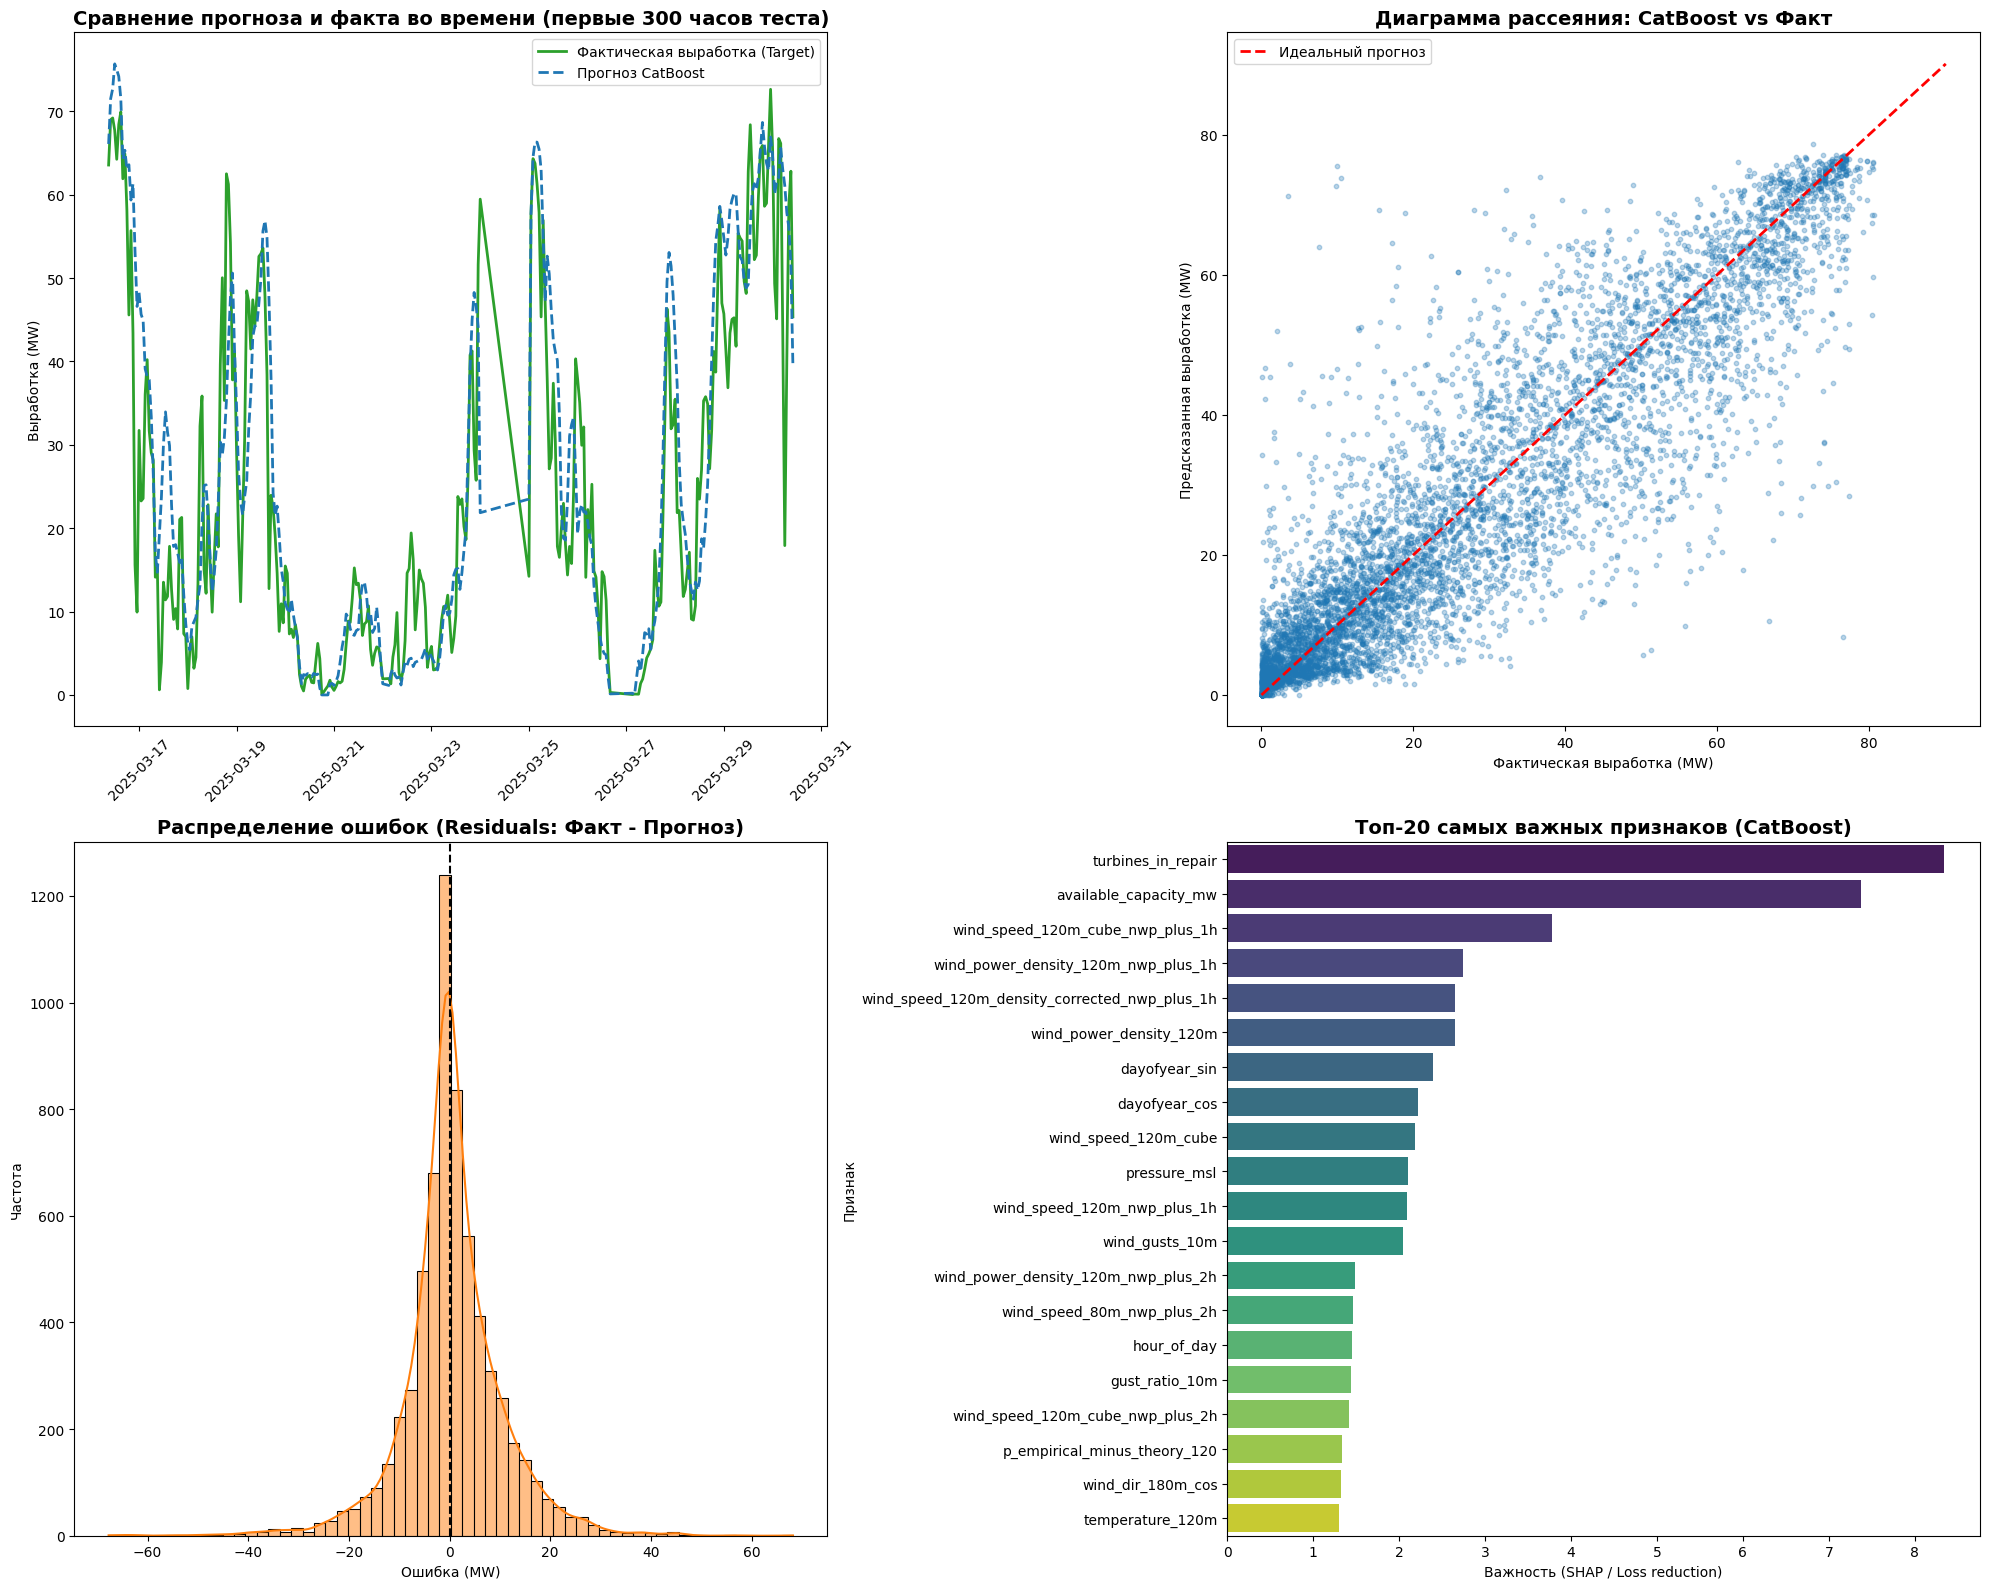

In [9]:
print("6. Анализ результатов (построение графиков)...")

# Чтобы графики были честными (у нас нет target в valid_fe), мы сделаем OOF-предсказание
# на последних 20% тренировочной выборки, чтобы сравнить модель с реальными данными.

split_idx = int(len(train_fe) * 0.8)
test_eval = train_fe.iloc[split_idx:].copy()

y_eval_true = test_eval["target"].clip(0, INSTALLED_CAPACITY_MW)
y_eval_pred = cat_model.predict(test_eval[features])
y_eval_pred = np.clip(y_eval_pred, 0, INSTALLED_CAPACITY_MW)

mae_score = mean_absolute_error(y_eval_true, y_eval_pred)
print(f"CatBoost OOF (Last 20%) MAE: {mae_score:.4f}")

fig = plt.figure(figsize=(20, 16))

# --- График 1: Временной ряд (срез в 300 часов) ---
ax1 = plt.subplot(2, 2, 1)
slice_idx = 300
ax1.plot(test_eval["datetime"].iloc[:slice_idx], y_eval_true.iloc[:slice_idx], label="Фактическая выработка (Target)", color="#2ca02c", linewidth=2)
ax1.plot(test_eval["datetime"].iloc[:slice_idx], y_eval_pred[:slice_idx], label="Прогноз CatBoost", color="#1f77b4", linestyle="--", linewidth=2)
ax1.set_title("Сравнение прогноза и факта во времени (первые 300 часов теста)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Выработка (MW)")
ax1.legend()
plt.xticks(rotation=45)

# --- График 2: Scatter Plot (Предсказание vs Факт) ---
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(y_eval_true, y_eval_pred, alpha=0.3, color="#1f77b4", s=10)
ax2.plot([0, INSTALLED_CAPACITY_MW], [0, INSTALLED_CAPACITY_MW], color="red", linestyle="--", linewidth=2, label="Идеальный прогноз")
ax2.set_title("Диаграмма рассеяния: CatBoost vs Факт", fontsize=14, fontweight="bold")
ax2.set_xlabel("Фактическая выработка (MW)")
ax2.set_ylabel("Предсказанная выработка (MW)")
ax2.legend()

# --- График 3: Распределение ошибок (Residuals) ---
ax3 = plt.subplot(2, 2, 3)
residuals = y_eval_true - y_eval_pred
sns.histplot(residuals, bins=60, kde=True, ax=ax3, color="#ff7f0e")
ax3.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax3.set_title("Распределение ошибок (Residuals: Факт - Прогноз)", fontsize=14, fontweight="bold")
ax3.set_xlabel("Ошибка (MW)")
ax3.set_ylabel("Частота")

# --- График 4: Важность признаков (Feature Importance) ---
ax4 = plt.subplot(2, 2, 4)
importances = cat_model.get_feature_importance()
feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(20)

sns.barplot(x="Importance", y="Feature", data=feat_imp, ax=ax4, palette="viridis")
ax4.set_title("Топ-20 самых важных признаков (CatBoost)", fontsize=14, fontweight="bold")
ax4.set_xlabel("Важность (SHAP / Loss reduction)")
ax4.set_ylabel("Признак")

plt.tight_layout()
plt.show()

## 8. Глубокая диагностика ошибок

In [ ]:
print("7. Глубокая диагностика ошибок модели (Поиск слабых мест)...")

# Подготовим DataFrame с результатами для удобства анализа
diagnostic_df = test_eval.copy()
diagnostic_df["target"] = y_eval_true
diagnostic_df["prediction"] = y_eval_pred
diagnostic_df["error"] = diagnostic_df["target"] - diagnostic_df["prediction"] # Положительная = недопрогноз, Отрицательная = перепрогноз
diagnostic_df["abs_error"] = diagnostic_df["error"].abs()

fig = plt.figure(figsize=(20, 16))

# --- График 1: Ошибка в зависимости от скорости ветра ---
# Помогает найти проблемы на границах работы турбины (cut-in ~3m/s, rated ~12m/s, cut-out ~25m/s)
ax1 = plt.subplot(2, 2, 1)
sns.scatterplot(x="wind_speed_120m", y="error", data=diagnostic_df, alpha=0.3, color="#d62728", s=15, ax=ax1)
ax1.axhline(0, color="black", linestyle="--", linewidth=2)
ax1.axvline(CUT_IN_SPEED, color="blue", linestyle=":", label="Cut-in (3 m/s)")
ax1.axvline(RATED_SPEED, color="green", linestyle=":", label="Rated (12 m/s)")
ax1.set_title("Ошибка vs Скорость ветра на 120м", fontsize=14, fontweight="bold")
ax1.set_xlabel("Скорость ветра (м/с)")
ax1.set_ylabel("Ошибка (Факт - Прогноз, MW)")
ax1.legend()

# --- График 2: Средняя абсолютная ошибка по часам суток ---
# Помогает выявить проблемы с суточными атмосферными явлениями (инверсии, бризы)
ax2 = plt.subplot(2, 2, 2)
sns.boxplot(x="hour_of_day", y="abs_error", data=diagnostic_df, ax=ax2, palette="coolwarm")
ax2.set_title("Абсолютная ошибка по времени суток", fontsize=14, fontweight="bold")
ax2.set_xlabel("Час суток")
ax2.set_ylabel("Абсолютная ошибка (MAE, MW)")

# --- График 3: Систематическое смещение (Гетероскедастичность) ---
# Проверяем: занижает ли модель пики? Завышает ли она нули?
ax3 = plt.subplot(2, 2, 3)
sns.scatterplot(x="target", y="prediction", data=diagnostic_df, alpha=0.2, color="#9467bd", s=15, ax=ax3)
ax3.plot([0, INSTALLED_CAPACITY_MW], [0, INSTALLED_CAPACITY_MW], color="black", linestyle="--", label="Идеал")

# Добавим линию тренда ошибок (Lowess)
sns.regplot(x="target", y="prediction", data=diagnostic_df, scatter=False, color="red", label="Тренд предсказаний", ax=ax3, lowess=True)

ax3.set_title("Факт vs Прогноз (Поиск занижений пиков)", fontsize=14, fontweight="bold")
ax3.set_xlabel("Фактическая выработка (MW)")
ax3.set_ylabel("Прогноз модели (MW)")
ax3.legend()

# --- График 4: Анализ "худших" предсказаний (Top 5% ошибок) ---
# Выделяем самые большие промахи и смотрим, при какой мощности они случились
ax4 = plt.subplot(2, 2, 4)
threshold_95 = diagnostic_df["abs_error"].quantile(0.95)
worst_cases = diagnostic_df[diagnostic_df["abs_error"] >= threshold_95]

sns.histplot(worst_cases["target"], bins=30, color="#ff7f0e", kde=True, ax=ax4, stat="density", label="Распределение факта при худших ошибках")
sns.histplot(diagnostic_df["target"], bins=30, color="gray", kde=True, ax=ax4, stat="density", alpha=0.3, label="Общее распределение факта")

ax4.set_title(f"Где модель ошибается сильнее всего? (Топ-5% ошибок > {threshold_95:.2f} MW)", fontsize=14, fontweight="bold")
ax4.set_xlabel("Фактическая выработка (MW)")
ax4.set_ylabel("Плотность вероятности")
ax4.set_yscale("log")
ax4.legend()

plt.tight_layout()
plt.show()

# --- Текстовая сводка по худшим ошибкам ---
print("\n--- Профиль худших ошибок (Топ-5%) ---")
print(f"Средняя скорость ветра при худших ошибках: {worst_cases['wind_speed_120m'].mean():.2f} м/с (в среднем по тесту: {diagnostic_df['wind_speed_120m'].mean():.2f} м/с)")
print(f"Доля турбин в ремонте при ошибках: {worst_cases['turbines_in_repair'].mean():.2f} (в среднем: {diagnostic_df['turbines_in_repair'].mean():.2f})")
print(f"Самый проблемный месяц: {worst_cases['month'].mode()[0]}")

## Где искать результат

После выполнения ноутбука основной submission лежит здесь:

```text
outputs/pipeline_755/submission_final_755.csv
```

Если хочешь сравнить именно `cat_mae_direct` отдельно от blend, смотри переменную:

```python
valid_predictions["cat_mae_direct"]
```

In [ ]:
print("Основной submission:", FINAL_SUBMISSION_PATH)

try:
    print("Файл существует:", FINAL_SUBMISSION_PATH.exists())
    if FINAL_SUBMISSION_PATH.exists():
        result = pd.read_csv(FINAL_SUBMISSION_PATH)
        print(result.shape)
        display(result.head(20))
        display(result.describe())
except Exception as e:
    print("Не удалось открыть submission:", e)